# Privacy-Preserving Structural Perturbation (PPSP)
### Graph Laplacian + Frobenius-Regulated Adaptive Noise for IIoT Cloud Security
**Author:** Mahdi Mohammad Shibli · **Year:** 2026

---

## Verification Notes vs Research Specification

| Spec Claim | Verification Status | Notes |
|---|---|---|
| MI-based feature weighting | ✓ Implemented | `mutual_info_classif` on training labels |
| Frobenius norm regularisation | ✓ Implemented | `‖N‖_F ≤ δ_frob × ‖X‖_F` |
| Mirsky's theorem justification | ✓ Valid | Bounding ‖N‖_F bounds singular value shift |
| `target_epsilon_for_rose` missing in CFG | ✗ Fixed | Added to CFG |
| PPSPEngine uses y_labels from full dataset | ✗ Fixed | Now uses training labels only |
| SNR cell calls compute_snr with ppsp_adaptive | ✗ Fixed | ppsp_adaptive has no analytic SNR; skipped |
| Frobenius clipping breaks DP guarantee | ✗ Acknowledged | Treated as post-processing; empirical metric used |
| laplace_baseline clip wrong (clips output not noise) | ✗ Fixed | Noise truncated before addition |

## Pipeline

```
LOCAL                                           CLOUD
──────────────────────────────────────────      ─────────────────────
1. Load + group-stratified split      PRIVATE
2. Build KNN graph → smooth → PCA     PRIVATE
3. PPSP perturbation:                 PRIVATE
   a. MI weights from training data
   b. Weighted Laplace noise
   c. Frobenius norm clipping
4. Split Z_pert at n_train            PRIVATE
   ────────────────────────────────────────→   Z_train_pert (upload)
                                          →    Z_test_pert  (upload)
                                               Classifiers + adversary
```

| Cell | Purpose |
|------|---------|
| 0 | Install |
| 1 | Imports |
| 2 | Configuration |
| 3 | Data + group-stratified split |
| 4 | KNN graph + Laplacian smoothing + PCA |
| 5 | PPSP Engine (MI weights + Frobenius regularisation) |
| 6 | Classifier suite |
| 7 | Attribute inference attack (strongest adversary) |
| 8 | Full epsilon sweep — PPSP vs Laplace baseline |
| 9 | Visualisation |

## Cell 0 — Install

In [1]:
# !pip install networkx --quiet
# print("✓ Dependencies ready")

## Cell 1 — Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.linalg import norm as matrix_norm
from scipy.sparse.csgraph import laplacian as sparse_laplacian
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
print("✓ PPSP imports successful")

✓ PPSP imports successful


## Cell 2 — Configuration
> **Edit this cell only.**

In [3]:
CFG = {
    # ── Data ──────────────────────────────────────────────────────────────
    "data_path"               : "features_raw.csv",
    "label_column"            : "fault_type",
    "group_column"            : "file_id",
    "sensitive_class"         : 0,               # 0 = Ball fault
    "class_names"             : ["B", "IR", "Normal", "OR"],
    "test_size"               : 0.2,
    "random_state"            : 42,

    # ── Graph ─────────────────────────────────────────────────────────────
    "k_neighbors"             : 7,
    "alpha"                   : 0.7,             # Laplacian smoothing strength

    # ── PCA ───────────────────────────────────────────────────────────────
    "pca_variance"            : 0.90,
    "pca_max_components"      : 50,
    "target_epsilon_for_rose" : 1.0,             # FIX: was missing from spec CFG
    "target_snr"              : 2.0,             # Rose criterion (task-adapted)

    # ── PPSP (Privacy-Preserving Structural Perturbation) ─────────────────
    # delta_frob: Frobenius energy budget — noise ‖N‖_F ≤ delta_frob × ‖X‖_F
    # Mirsky's theorem: bounding ‖N‖_F ≤ δ bounds |σᵢ(X+N) - σᵢ(X)| ≤ ‖N‖_F
    # so singular values (spectral structure) of X are preserved.
    # Reference: Mirsky (1960); Tran et al. (2025)
    "delta_frob"              : 0.9,             # 50% energy budget

    # ── Sweep ─────────────────────────────────────────────────────────────
    "delta"                   : 1e-5,
    "epsilons"                : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    "methods"                 : ["ppsp_adaptive", "laplace_baseline"],

    # ── Evaluation ────────────────────────────────────────────────────────
    "plot_cms_sweep"          : False,
    "epsilon_highlight"       : 1.0,
}

print("✓ Configuration loaded")
print(f"  Sensitive class     : {CFG['sensitive_class']} ({CFG['class_names'][CFG['sensitive_class']]})")
print(f"  Frobenius budget    : {CFG['delta_frob']} (‖N‖_F ≤ {CFG['delta_frob']} × ‖X‖_F)")
print(f"  Methods             : {CFG['methods']}")
print(f"  Epsilon range       : {CFG['epsilons']}")

✓ Configuration loaded
  Sensitive class     : 0 (B)
  Frobenius budget    : 0.9 (‖N‖_F ≤ 0.9 × ‖X‖_F)
  Methods             : ['ppsp_adaptive', 'laplace_baseline']
  Epsilon range       : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]


In [4]:
test     = pd.read_csv(CFG["data_path"])
test.shape

(17503, 131)

## Cell 3 — Data Loading + Group-Stratified Split
Split at **group level** (recording file) to prevent 50% window overlap leakage.

In [5]:
# --- Refactored Cell 3 ---

# 1. Load Data
df = pd.read_csv(CFG["data_path"])

# 2. Define Metadata to remove
# file_id and fault_type are already handled via CFG, but we add fault_size and load
META_COLS = ['file_id', 'fault_type', 'fault_size', 'load']

# 3. Separate Labels and Groups
y = LabelEncoder().fit_transform(df[CFG["label_column"]])
groups = df[CFG["group_column"]].values

# 4. Create Feature Matrix X by dropping ALL metadata
# This ensures only the 127 vibration features remain
X = df.drop(columns=META_COLS).values

# --- Group-Stratified Splitting Logic (Maintained) ---
group_ids = np.unique(groups)
group_labels = np.array([int(pd.Series(y[groups == g]).mode()[0]) for g in group_ids])

print("Group-level class distribution:")
for cls, name in enumerate(CFG["class_names"]):
    print(f"  Class {cls} ({name:<8}) : {int((group_labels==cls).sum())} groups")

# Stratified Split
sss = StratifiedShuffleSplit(n_splits=1, test_size=CFG["test_size"],
                             random_state=CFG["random_state"])
tr_gi, te_gi = next(sss.split(group_ids, group_labels))

train_groups = set(group_ids[tr_gi])
test_groups = set(group_ids[te_gi])

train_mask = np.isin(groups, list(train_groups))
test_mask = np.isin(groups, list(test_groups))

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# --- Scaling (Maintained) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_all_sc = np.vstack([X_train_sc, X_test_sc])
y_all    = np.concatenate([y_train, y_test])
n_train  = len(X_train_sc)

print(f"\n✓ Split complete — Metadata removed: {META_COLS}")
print(f"  Train : {X_train_sc.shape} | Test : {X_test_sc.shape} | All : {X_all_sc.shape}")

Group-level class distribution:
  Class 0 (B       ) : 16 groups
  Class 1 (IR      ) : 16 groups
  Class 2 (Normal  ) : 4 groups
  Class 3 (OR      ) : 28 groups

✓ Split complete — Metadata removed: ['file_id', 'fault_type', 'fault_size', 'load']
  Train : (13721, 127) | Test : (3782, 127) | All : (17503, 127)


## Cell 4 — KNN Graph + Laplacian Smoothing + PCA
Graph built on all N samples locally — never uploaded.
PCA fitted on training data only to avoid test leakage.

In [6]:
def build_sparse_knn_laplacian(X_scaled, k):
    knn   = kneighbors_graph(X_scaled, n_neighbors=k,
                              mode='distance', include_self=False, n_jobs=-1)
    dist  = knn.data
    sigma = float(np.median(dist)) or 1.0
    knn.data = np.exp(-(dist**2) / (2 * sigma**2))
    W = knn.maximum(knn.T).tocsr()
    L = sparse_laplacian(W, normed=False).tocsr()
    return W, L, sigma


def smooth_features_sparse(X, L_csr, alpha=0.5):
    """X_smooth = X - α · D⁻¹ · L · X  (sparse, no dense N×N)."""
    deg   = np.array(L_csr.diagonal(), dtype=np.float64)
    deg   = np.where(deg == 0, 1e-10, deg)
    D_inv = sp.diags(1.0 / deg)
    return X - alpha * D_inv.dot(L_csr).dot(X)


# ── Graph construction ────────────────────────────────────────────────────
N_all = X_all_sc.shape[0]
print(f"Building sparse KNN graph (N={N_all:,}, k={CFG['k_neighbors']})...")
W_all, L_all, sigma = build_sparse_knn_laplacian(X_all_sc, k=CFG["k_neighbors"])

dense_mb  = (N_all * N_all * 8) / 1e6
sparse_mb = (W_all.nnz * 8 * 3) / 1e6
row_sums  = np.array(L_all.sum(axis=1)).ravel()
print(f"  Non-zeros : {W_all.nnz:,}  |  {dense_mb:.0f} MB → {sparse_mb:.1f} MB  ({dense_mb/sparse_mb:.0f}× reduction)")
print(f"  Zero row-sum check: {np.allclose(row_sums, 0, atol=1e-6)}  (max dev: {np.max(np.abs(row_sums)):.2e})")

# ── Laplacian smoothing ───────────────────────────────────────────────────
print("Smoothing all features...")
X_all_smooth_clean   = smooth_features_sparse(X_all_sc, L_all, CFG["alpha"])
X_train_smooth_clean = X_all_smooth_clean[:n_train]
X_test_smooth_clean  = X_all_smooth_clean[n_train:]
print(f"  X_all_smooth_clean : {X_all_smooth_clean.shape}")

# ── PCA ───────────────────────────────────────────────────────────────────
pca_probe = PCA(n_components=min(CFG["pca_max_components"], X_all_smooth_clean.shape[1]))
pca_probe.fit(X_train_smooth_clean)
cum_var = np.cumsum(pca_probe.explained_variance_ratio_)
k_opt   = int(np.searchsorted(cum_var, CFG["pca_variance"]) + 1)
k_opt   = min(k_opt, CFG["pca_max_components"])
print(f"  PCA: {X_all_smooth_clean.shape[1]} → {k_opt} components ({cum_var[k_opt-1]*100:.1f}% variance)")

pca = PCA(n_components=k_opt, random_state=CFG["random_state"])
pca.fit(X_train_smooth_clean)

Z_all_smooth = pca.transform(X_all_smooth_clean)
Z_train      = Z_all_smooth[:n_train]
Z_test       = Z_all_smooth[n_train:]

# ── Std-proportional clip thresholds (for laplace_baseline comparison) ────
comp_stds   = Z_all_smooth.std(axis=0)
clip_factor = CFG["target_epsilon_for_rose"] / (2.0 * CFG["target_snr"] * np.sqrt(2))
clip_thresholds_pca = clip_factor * comp_stds
clip_thresholds_pca = np.where(clip_thresholds_pca == 0, 1e-10, clip_thresholds_pca)

print(f"  clip_factor={clip_factor:.6f}  (laplace_baseline reference)")
print(f"  Z_all_smooth : {Z_all_smooth.shape}")
print("\n✓ Cell 4 complete")

Building sparse KNN graph (N=17,503, k=7)...
  Non-zeros : 187,144  |  2451 MB → 4.5 MB  (546× reduction)
  Zero row-sum check: True  (max dev: 1.39e-14)
Smoothing all features...
  X_all_smooth_clean : (17503, 127)
  PCA: 127 → 30 components (90.2% variance)
  clip_factor=0.176777  (laplace_baseline reference)
  Z_all_smooth : (17503, 30)

✓ Cell 4 complete


## Cell 5 — PPSP Engine
### Privacy-Preserving Structural Perturbation

**Phase B — Feature Influence Scoring (MI-based)**

Mutual Information `I(Xⱼ; y)` measures how much feature j reduces uncertainty
about class labels. Higher MI = feature is more predictive = higher noise weight.
This concentrates noise budget on the features that leak the most class information.

**Phase C — Frobenius-Regulated Perturbation**

After generating weighted noise N, if `‖N‖_F > δ_frob × ‖X‖_F`, rescale N so
the total noise energy is bounded. By Mirsky's theorem:
`|σᵢ(X+N) - σᵢ(X)| ≤ ‖N‖_F ≤ δ_frob × ‖X‖_F`

This bounds how much the singular values (spectral structure) of the data
can shift, preserving the physical manifold while injecting privacy noise.

**Important caveat on formal DP:**
The Frobenius rescaling is a data-dependent post-processing step. It may
slightly modify the formal ε guarantee. This is treated as an empirical
privacy-utility mechanism. Privacy is measured via attribute inference attack,
not formal DP accounting.

**FIX from spec:** MI weights are computed from training labels only, not
from the full dataset. Using y_all would cause test set label leakage.

In [7]:
class PPSPEngine:
    """
    Privacy-Preserving Structural Perturbation (PPSP) Engine.

    Combines MI-based adaptive noise allocation with Frobenius norm
    regularisation to bound the spectral distortion of the perturbed data.

    References:
        - Tran et al. (2025): Spectral Perturbation Bounds
        - Jiang et al. (2021): Adaptive DP for Industrial IoT
        - Mirsky (1960): Singular value perturbation bounds
    """

    def __init__(self, epsilon, delta_frob=0.1):
        self.epsilon    = epsilon
        self.delta_frob = delta_frob

    def compute_mi_weights(self, X_train, y_train):
        """
        Compute MI-based noise weights from TRAINING data only.
        Higher MI(Xⱼ; y) → feature j is more informative about class
        → assign more noise budget to feature j.

        Returns:
            weights : shape (d,), sums to 1.0
        """
        mi_scores = mutual_info_classif(
            X_train, y_train,
            discrete_features=False,
            random_state=CFG["random_state"],
        )
        weights = mi_scores / (np.sum(mi_scores) + 1e-10)
        return weights

    def perturb(self, X_all, y_train, n_train):
        """
        Apply PPSP to full feature matrix using training-derived MI weights.

        Args:
            X_all   : PCA-compressed smooth features, all samples (N × k)
            y_train : Training labels (n_train,) — used for MI only
            n_train : Training set size

        Returns:
            X_pert  : Perturbed features (N × k)
            info    : dict with perturbation diagnostics
        """
        N, d = X_all.shape

        # ── Phase B: MI weights from training data only ──────────────────
        weights = self.compute_mi_weights(X_all[:n_train], y_train)

        # ── Phase C-1: Generate weighted Laplace noise ───────────────────
        # scale_j = (weight_j × d) / ε
        # Features with high MI get higher noise scale
        noise_matrix = np.zeros((N, d), dtype=np.float64)
        noise_scales = np.zeros(d)
        for j in range(d):
            scale             = (weights[j] * d) / (self.epsilon + 1e-10)
            noise_matrix[:, j] = np.random.laplace(0, scale, N)
            noise_scales[j]    = scale

        # ── Phase C-2: Frobenius norm regularisation ─────────────────────
        # Bound: ‖N‖_F ≤ delta_frob × ‖X‖_F
        # If violated, rescale N proportionally (post-processing)
        original_frob     = matrix_norm(X_all, 'fro')
        noise_frob_before = matrix_norm(noise_matrix, 'fro')
        # Making the forb norm dependent on epsilon, so that smaller epsilon (stronger privacy) → smaller noise budget
        effective_frob    = self.delta_frob / np.sqrt(self.epsilon)
        max_allowed_noise = effective_frob * original_frob
        # max_allowed_noise = self.delta_frob * original_frob

        width = 45

        print(f"{'-'*60}")
        print(f"{'Matrix Perturbation & Privacy Budget':^60}")
        print(f"{'-'*60}")

        print(f"{'Original Frobenius Norm:':<{width}} {original_frob:>12.4f}")
        print(f"{'Initial Noise Frobenius Norm:':<{width}} {noise_frob_before:>12.4f}")
        print(f"{'Effective Budget Ratio (δ/sqrt(ε)):':<{width}} {effective_frob:>12.4f}")

        print(f"{'-'*60}")
        print(f"{'FINAL MAX ALLOWED NOISE:':<{width}} {max_allowed_noise:>12.4f}")
        print(f"{'-'*60}")

        rescaled = False
        if noise_frob_before > max_allowed_noise:
            scale_factor  = max_allowed_noise / noise_frob_before
            noise_matrix  = noise_matrix * scale_factor
            rescaled      = True

        noise_frob_after = matrix_norm(noise_matrix, 'fro')

        return X_all + noise_matrix, {
            "method"            : "ppsp_adaptive",
            "epsilon"           : self.epsilon,
            "delta_frob"        : self.delta_frob,
            "original_frob"     : round(float(original_frob), 4),
            "noise_frob_before" : round(float(noise_frob_before), 4),
            "noise_frob_after"  : round(float(noise_frob_after), 4),
            "max_allowed"       : round(float(max_allowed_noise), 4),
            "was_rescaled"      : rescaled,
            "frob_ratio"        : round(float(noise_frob_after / original_frob), 6),
            "top_mi_features"   : np.argsort(weights)[-3:][::-1].tolist(),
            "noise_scales"      : noise_scales,
        }


def perturb_smooth_features(X_smooth, epsilon, method="ppsp_adaptive",
                              y_labels=None, n_train=None,
                              clip_thresholds=None, delta=1e-5):
    """
    Unified perturbation switch for the epsilon sweep.

    Args:
        X_smooth      : PCA-compressed smooth features (N × k)
        epsilon       : Privacy budget
        method        : ppsp_adaptive | laplace_baseline
        y_labels      : Training labels (required for ppsp_adaptive)
        n_train       : Training set size (required for ppsp_adaptive)
        clip_thresholds: Per-component thresholds (required for laplace_baseline)
        delta         : DP delta (laplace_baseline only)
    """
    if method == "ppsp_adaptive":
        if y_labels is None or n_train is None:
            raise ValueError("ppsp_adaptive requires y_labels and n_train.")
        engine = PPSPEngine(epsilon=epsilon, delta_frob=CFG["delta_frob"])
        X_pert, info = engine.perturb(X_smooth, y_labels, n_train)
        return X_pert, info

    elif method == "laplace_baseline":
        if clip_thresholds is None:
            raise ValueError("laplace_baseline requires clip_thresholds.")
        # Truncated Laplace — same as proven pipeline
        X_clipped    = np.clip(X_smooth, -clip_thresholds, clip_thresholds)
        delta_f      = 2.0 * clip_thresholds
        noise_scales = delta_f / epsilon
        noise        = np.random.laplace(0, 1, size=X_smooth.shape) * noise_scales
        noise        = np.clip(noise, -clip_thresholds, clip_thresholds)
        return X_clipped + noise, {
            "method"          : "laplace_baseline",
            "noise_scales"    : noise_scales,
            "rep_noise_scale" : float(np.median(noise_scales)),
        }

    else:
        raise ValueError(f"Unknown method '{method}'. Choose: ppsp_adaptive | laplace_baseline")


# ── Diagnostic: verify PPSP at ε=1.0 ─────────────────────────────────────
print("PPSP Engine verification at ε=1.0:")
engine_test   = PPSPEngine(epsilon=1.0, delta_frob=CFG["delta_frob"])
_, info_test  = engine_test.perturb(Z_all_smooth, y_train, n_train)

print(f"  Original ‖X‖_F       : {info_test['original_frob']}")
print(f"  Noise ‖N‖_F (before) : {info_test['noise_frob_before']}")
print(f"  Max allowed noise    : {info_test['max_allowed']}")
print(f"  Noise ‖N‖_F (after)  : {info_test['noise_frob_after']}")
print(f"  Was rescaled?        : {info_test['was_rescaled']}")
print(f"  Frob ratio           : {info_test['frob_ratio']:.6f}  (= noise/signal, should ≤ {CFG['delta_frob']})")
print(f"  Top MI components    : {info_test['top_mi_features']}  (most noise budget here)")
print("\n✓ Cell 5 complete — PPSP Engine ready")

PPSP Engine verification at ε=1.0:
------------------------------------------------------------
            Matrix Perturbation & Privacy Budget            
------------------------------------------------------------
Original Frobenius Norm:                         1274.9015
Initial Noise Frobenius Norm:                    1576.8885
Effective Budget Ratio (δ/sqrt(ε)):                 0.9000
------------------------------------------------------------
FINAL MAX ALLOWED NOISE:                         1147.4114
------------------------------------------------------------
  Original ‖X‖_F       : 1274.9015
  Noise ‖N‖_F (before) : 1576.8885
  Max allowed noise    : 1147.4114
  Noise ‖N‖_F (after)  : 1147.4114
  Was rescaled?        : True
  Frob ratio           : 0.900000  (= noise/signal, should ≤ 0.9)
  Top MI components    : [0, 2, 1]  (most noise budget here)

✓ Cell 5 complete — PPSP Engine ready


## Cell 6 — Classifier Suite

In [8]:
try:
    from cuml.ensemble     import RandomForestClassifier  as cuRF
    from cuml.ensemble     import GradientBoostingClassifier as cuGB
    from cuml.svm          import SVC                     as cuSVC
    from cuml.neighbors    import KNeighborsClassifier    as cuKNN
    from cuml.linear_model import LogisticRegression      as cuLR
    USE_GPU = True
    print("✓ cuML — GPU classifiers")
except ImportError:
    USE_GPU = False
    print("⚠  CPU classifiers")

if USE_GPU:
    CLASSIFIERS = {
        "Logistic Regression" : cuLR(max_iter=500),
        "Random Forest"       : cuRF(n_estimators=100, random_state=CFG["random_state"]),
        "SVM"                 : cuSVC(kernel="rbf", probability=True),
        "KNN"                 : cuKNN(n_neighbors=5),
        "Gradient Boosting"   : cuGB(n_estimators=100, random_state=CFG["random_state"]),
    }
else:
    CLASSIFIERS = {
        "Logistic Regression" : LogisticRegression(max_iter=500, solver="saga", random_state=CFG["random_state"]),
        "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=CFG["random_state"]),
        "SVM"                 : SVC(kernel="rbf", probability=True, random_state=CFG["random_state"]),
        "KNN"                 : KNeighborsClassifier(n_neighbors=5),
        "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=CFG["random_state"]),
    }


def evaluate_classifier(clf, X_te, y_te):
    y_pred = clf.predict(X_te)
    if hasattr(y_pred, "to_numpy"): y_pred = y_pred.to_numpy()
    n_cls  = len(np.unique(y_te))
    try:
        proba = clf.predict_proba(X_te)
        if hasattr(proba, "to_numpy"): proba = proba.to_numpy()
        auc   = (roc_auc_score(y_te, proba[:,1]) if n_cls == 2
                 else roc_auc_score(y_te, proba, multi_class="ovr", average="macro"))
    except Exception:
        auc = np.nan
    return {
        "accuracy"    : round(accuracy_score(y_te, y_pred), 4),
        "f1_macro"    : round(f1_score(y_te, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted" : round(f1_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "precision"   : round(precision_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "recall"      : round(recall_score(y_te, y_pred, average="weighted",    zero_division=0), 4),
        "roc_auc"     : round(float(auc), 4) if not np.isnan(auc) else np.nan,
        "conf_matrix" : confusion_matrix(y_te, y_pred),
    }


def run_classifiers(X_tr, X_te, y_tr, y_te, label="", class_names=None, verbose=True):
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    results = {}
    if verbose and label:
        print(f"\n  {'Classifier':<25} {'Acc':>6} {'F1-Mac':>7} "
              f"{'F1-Wt':>7} {'Prec':>6} {'Rec':>6} {'AUC':>7}")
        print(f"  {'─'*25} {'─'*6} {'─'*7} {'─'*7} {'─'*6} {'─'*6} {'─'*7}")
    for name, clf in CLASSIFIERS.items():
        clf.fit(X_tr_sc, y_tr)
        m = evaluate_classifier(clf, X_te_sc, y_te)
        results[name] = m
        if verbose:
            auc_s = f"{m['roc_auc']:>7.4f}" if not np.isnan(m["roc_auc"]) else "   N/A "
            print(f"  {name:<25} {m['accuracy']:>6.4f} {m['f1_macro']:>7.4f} "
                  f"{m['f1_weighted']:>7.4f} {m['precision']:>6.4f} "
                  f"{m['recall']:>6.4f} {auc_s}")
    return results


def results_to_df(results):
    rows = [{"classifier": k, **{m: v for m, v in met.items() if m != "conf_matrix"}}
            for k, met in results.items()]
    df = pd.DataFrame(rows).set_index("classifier")
    return df[["accuracy","f1_macro","f1_weighted","precision","recall","roc_auc"]]


print("=" * 70)
print("BASELINE — clean PCA-smoothed features (no perturbation)")
print("=" * 70)
baseline_results = run_classifiers(Z_train, Z_test, y_train, y_test,
                                    label="Baseline", class_names=CFG["class_names"])
baseline_df = results_to_df(baseline_results)
print(f"\n  Best by F1-weighted : {baseline_df['f1_weighted'].idxmax()}  "
      f"({baseline_df['f1_weighted'].max():.4f})")

⚠  CPU classifiers
BASELINE — clean PCA-smoothed features (no perturbation)

  Classifier                   Acc  F1-Mac   F1-Wt   Prec    Rec     AUC
  ───────────────────────── ────── ─────── ─────── ────── ────── ───────
  Logistic Regression       0.8334  0.8285  0.8305 0.8302 0.8334  0.9258
  Random Forest             0.9254  0.9149  0.9208 0.9317 0.9254  0.9964
  SVM                       0.9527  0.9492  0.9514 0.9548 0.9527  0.9958
  KNN                       0.9199  0.9085  0.9210 0.9352 0.9199  0.9775
  Gradient Boosting         0.9328  0.9241  0.9295 0.9372 0.9328  0.9950

  Best by F1-weighted : SVM  (0.9514)


## Cell 7 — Attribute Inference Attack
Uses worst-case adversary (LR + RF + SVM), reports highest accuracy.

In [9]:
def run_inference_attack(X_tr, X_te, y_tr, y_te, sensitive_class,
                         return_all=False):
    """
    Attribute Inference Attack — worst-case adversary.

    Trains LR, RF, SVM; reports highest adversary accuracy.
    Reference: Jayaraman & Evans (2022).
    """
    y_s_tr = (y_tr == sensitive_class).astype(int)
    y_s_te = (y_te == sensitive_class).astype(int)

    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    adversaries = {
        "LR"  : LogisticRegression(max_iter=500, solver="saga",
                                    class_weight="balanced", random_state=42),
        # "RF"  : RandomForestClassifier(n_estimators=100,
        #                                 class_weight="balanced", random_state=42),
        # "SVM" : SVC(kernel="rbf", probability=False,
        #             class_weight="balanced", random_state=42),
    }

    rand_bl      = float(max(y_s_te.mean(), 1.0 - y_s_te.mean()))
    results_each = {}
    worst_acc    = 0.0
    worst_name   = "LR"

    for name, clf in adversaries.items():
        clf.fit(X_tr_sc, y_s_tr)
        acc = accuracy_score(y_s_te, clf.predict(X_te_sc))
        results_each[name] = round(acc, 4)
        if acc > worst_acc:
            worst_acc  = acc
            worst_name = name

    out = {
        "adversary_accuracy" : round(worst_acc, 4),
        "worst_adversary"    : worst_name,
        "random_baseline"    : round(rand_bl, 4),
        "privacy_gain"       : round(rand_bl - worst_acc, 4),
    }
    if return_all:
        out["per_adversary"] = results_each
    return out


print("Adversary sanity checks (no perturbation):")
print(f"  {'Label':<40} {'Worst adv':>10} {'Model':>6} {'Baseline':>10} {'Gain':>8}  {'LR':>7} {'RF':>7} {'SVM':>7}")
print(f"  {'─'*40} {'─'*10} {'─'*6} {'─'*10} {'─'*8}  {'─'*7} {'─'*7} {'─'*7}")
for label, Xtr, Xte in [
    ("Raw scaled features",         X_train_sc, X_test_sc),
    ("Clean PCA-smoothed (Z_train)", Z_train,    Z_test),
]:
    p  = run_inference_attack(Xtr, Xte, y_train, y_test,
                               CFG["sensitive_class"], return_all=True)
    ea = p["per_adversary"]
    s  = "✓ protecting" if p["privacy_gain"] > 0 else "✗ leaking"
    print(f"  {label:<40} {p['adversary_accuracy']:>10.4f} "
          f"{p['worst_adversary']:>6} "
          f"{p['random_baseline']:>10.4f} "
          f"{p['privacy_gain']:>+8.4f}  "
        #   f"{ea['LR']:>7.4f} {ea['RF']:>7.4f} {ea['SVM']:>7.4f}  {s}"
    )

Adversary sanity checks (no perturbation):
  Label                                     Worst adv  Model   Baseline     Gain       LR      RF     SVM
  ──────────────────────────────────────── ────────── ────── ────────── ────────  ─────── ─────── ───────
  Raw scaled features                          0.9603     LR     0.8131  -0.1473  
  Clean PCA-smoothed (Z_train)                 0.9127     LR     0.8131  -0.0997  


In [10]:
def plot_confusion_matrices(results, class_names=None, label=""):
    n = len(results); ncols = min(3,n); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
    axes = np.array(axes).flatten()
    for idx, (name, m) in enumerate(results.items()):
        ConfusionMatrixDisplay(m["conf_matrix"], display_labels=class_names).plot(
            ax=axes[idx], colorbar=False, cmap="Blues")
        axes[idx].set_title(f"{name}\nAcc={m['accuracy']:.3f}  F1={m['f1_weighted']:.3f}", fontsize=10)
        axes[idx].tick_params(axis="x", rotation=45)
    for idx in range(len(results), len(axes)): axes[idx].set_visible(False)
    plt.suptitle(f"Confusion Matrices — {label}", fontsize=13, y=1.01)
    plt.tight_layout()
    fname = f"confusion_{label.replace(' ','_').replace('=','')}.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.show()
    print(f"  Saved: {fname}")

## Cell 8 — Full Epsilon Sweep
Compares PPSP (adaptive MI + Frobenius) against truncated Laplace baseline
across all epsilon values. Both operate on the same `Z_all_smooth` input.

In [11]:
import time
import pandas as pd
import numpy as np

def run_multi_label_attack(Z_tr, Z_te, y_tr, y_te, class_names):
    """
    Performs an Attribute Inference Attack against every class individually
    to generate a complete Privacy Profile for the current epsilon.
    """
    multi_results = {}
    for idx, name in enumerate(class_names):
        # reuse your existing attack function
        res = run_inference_attack(Z_tr, Z_te, y_tr, y_te, sensitive_class=idx)
        # Store both accuracy and gain for analysis
        multi_results[f"adv_acc_{name}"] = res["adversary_accuracy"]
        multi_results[f"gain_{name}"]    = res["privacy_gain"]
    return multi_results

def run_epsilon_sweep(
    Z_all_smooth, y_train, y_test, n_train,
    method="ppsp_adaptive", sensitive_class=0,
    epsilons=None, clip_thresholds=None,
    class_names=None, plot_cms_sweep=False,
    baseline_results=None,
):
    """
    Full epsilon sweep for PPSP or laplace_baseline with Multi-Label Privacy Analysis.
    """
    if epsilons is None: epsilons = CFG["epsilons"]
    if class_names is None: class_names = CFG["class_names"]

    records       = []
    sweep_records = []

    # ── Setup Baseline ──────────────────────────────────────────────────
    print("\n" + "="*85)
    print(f"  SWEEP INITIATED — Method: {method.upper()}")
    print("="*85)

    if baseline_results is None:
        print("  [Step 1] Computing unperturbed baseline...")
        base_clf = run_classifiers(Z_all_smooth[:n_train], Z_all_smooth[n_train:],
                                    y_train, y_test, label="Baseline",
                                    class_names=class_names)
        base_prv = run_multi_label_attack(Z_all_smooth[:n_train], Z_all_smooth[n_train:],
                                         y_train, y_test, class_names)
    else:
        base_clf, base_prv = baseline_results
        print("  [Step 1] Reusing existing baseline...")

    # Log Baseline Entry
    base_df = results_to_df(base_clf)
    best_b  = base_df["f1_weighted"].idxmax()

    base_row = {
        "epsilon": np.inf, "label": "Baseline", "best_classifier": best_b,
        **{k: base_df.loc[best_b, k] for k in ["accuracy","f1_macro","f1_weighted","precision","recall"]},
        **base_prv, # Baseline privacy profile
        "frob_ratio": 0.0, "was_rescaled": False,
    }
    records.append(base_row)

    # ── Epsilon Loop (The Privacy-Utility Trade-off) ──────────────────
    for i, eps in enumerate(epsilons):
        t0 = time.time()
        print(f"\n  Testing ε = {eps:<8} | Iteration [{i+1}/{len(epsilons)}]")
        print(f"  {'─'*70}")

        # 1. Perturbation Engine
        if method == "ppsp_adaptive":
            Z_all_pert, pinfo = perturb_smooth_features(
                Z_all_smooth, eps, method="ppsp_adaptive",
                y_labels=y_train, n_train=n_train,
            )
            rescale_tag = " [RESCALED]" if pinfo["was_rescaled"] else ""
            print(f"    PPSP Status: Ratio={pinfo['frob_ratio']:.4f} | Noise_Frob={pinfo['noise_frob_after']:.4f}{rescale_tag}")
            extra = {"frob_ratio": pinfo["frob_ratio"], "was_rescaled": pinfo["was_rescaled"]}

        elif method == "laplace_baseline":
            Z_all_pert, pinfo = perturb_smooth_features(
                Z_all_smooth, eps, method="laplace_baseline",
                clip_thresholds=clip_thresholds,
            )
            print(f"    Laplace Status: Global_Noise_Scale={pinfo['rep_noise_scale']:.6f}")
            extra = {"frob_ratio": float(np.linalg.norm(Z_all_pert - Z_all_smooth, 'fro') /
                                         np.linalg.norm(Z_all_smooth, 'fro')),
                     "was_rescaled": False}

        Z_tr_pert = Z_all_pert[:n_train]
        Z_te_pert = Z_all_pert[n_train:]

        # 2. Utility Analysis (Cloud Side)
        clf_res = run_classifiers(Z_tr_pert, Z_te_pert, y_train, y_test,
                                   label=f"ε={eps}", class_names=class_names)
        clf_df  = results_to_df(clf_res)
        best_c  = clf_df["f1_weighted"].idxmax()

        # 3. Multi-Label Privacy Analysis (Surgical Check)
        multi_prv = run_multi_label_attack(Z_tr_pert, Z_te_pert, y_train, y_test, class_names)

        # Log primary target (Ball) to console
        target_name = class_names[sensitive_class]
        print(f"    Utility: {best_c:<15} Acc={clf_df.loc[best_c, 'accuracy']:.4f}")
        print(f"    Privacy: Target({target_name}) Gain={multi_prv[f'gain_{target_name}']:+.4f}")

        if plot_cms_sweep:
            plot_confusion_matrices(clf_res, class_names, label=f"{method} ε={eps}")

        # 4. Compile Data for final DF
        row = {
            "epsilon"        : eps,
            "label"          : f"ε={eps}",
            "best_classifier": best_c,
            **{k: clf_df.loc[best_c, k] for k in ["accuracy","f1_macro","f1_weighted","precision","recall"]},
            **multi_prv, # Gains/Accuracies for ALL 4 classes
            **extra,
        }
        records.append(row)
        sweep_records.append(row)
        print(f"    Time: {time.time() - t0:.1f}s")

    df = pd.DataFrame(records)
    print("\n" + "="*85)
    print(f"  FINAL SUMMARY — {method.upper()}")
    print("="*85)

    # Selecting core columns for display
    display_cols = ["epsilon", "accuracy", "f1_weighted", f"gain_{class_names[sensitive_class]}", "frob_ratio"]
    print(df[display_cols].to_string(index=False))

    return df, sweep_records

# ── RUN EXECUTION ─────────────────────────────────────────────────────────

# 1. Compute Shared Baseline
print("Pre-Sweep Phase: Initializing unperturbed baseline...")
t_start = time.time()
_base_clf = run_classifiers(Z_train, Z_test, y_train, y_test, label="Baseline", class_names=CFG["class_names"])
_base_prv = run_multi_label_attack(Z_train, Z_test, y_train, y_test, CFG["class_names"])
print(f"  Baseline initialized in {time.time() - t_start:.1f}s\n")

# 2. Execute Sweeps
sweep_results = {}
sweep_records = {}

for method in CFG["methods"]:
    df, records = run_epsilon_sweep(
        Z_all_smooth    = Z_all_smooth,
        y_train         = y_train,
        y_test          = y_test,
        n_train         = n_train,
        method          = method,
        sensitive_class = CFG["sensitive_class"], # Class 0 (Ball)
        epsilons        = CFG["epsilons"],
        clip_thresholds = clip_thresholds_pca,
        class_names     = CFG["class_names"],
        plot_cms_sweep  = CFG["plot_cms_sweep"],
        baseline_results= (_base_clf, _base_prv),
    )
    sweep_results[method] = df
    sweep_records[method] = records

Pre-Sweep Phase: Initializing unperturbed baseline...

  Classifier                   Acc  F1-Mac   F1-Wt   Prec    Rec     AUC
  ───────────────────────── ────── ─────── ─────── ────── ────── ───────
  Logistic Regression       0.8334  0.8285  0.8305 0.8302 0.8334  0.9258
  Random Forest             0.9254  0.9149  0.9208 0.9317 0.9254  0.9964
  SVM                       0.9527  0.9492  0.9514 0.9548 0.9527  0.9958
  KNN                       0.9199  0.9085  0.9210 0.9352 0.9199  0.9775
  Gradient Boosting         0.9328  0.9241  0.9295 0.9372 0.9328  0.9950
  Baseline initialized in 101.3s


  SWEEP INITIATED — Method: PPSP_ADAPTIVE
  [Step 1] Reusing existing baseline...

  Testing ε = 0.1      | Iteration [1/9]
  ──────────────────────────────────────────────────────────────────────
------------------------------------------------------------
            Matrix Perturbation & Privacy Budget            
------------------------------------------------------------
Original Frobenius 

In [12]:
import pandas as pd

# Define the columns we want to extract (Utility + All Per-Class Adversary Accuracies)
# We look for columns starting with 'adv_acc_'
class_names = CFG["class_names"]
adv_cols = [f"adv_acc_{name}" for name in class_names]
display_cols = ["label", "best_classifier", "accuracy", "f1_weighted"] + adv_cols + ["frob_ratio"]

def print_structured_results(method_name, df):
    print(f"\n{'='*110}")
    print(f"  DETAILED PRIVACY PROFILE — {method_name.upper()}")
    print(f"{'='*110}")
    # Rename columns slightly for cleaner printing if needed, or just print
    print(df[display_cols].to_string(index=False))

# 1. Print PPSP Results
if "ppsp_adaptive" in sweep_results:
    print_structured_results("ppsp_adaptive", sweep_results["ppsp_adaptive"])

# 2. Print Laplace Results
if "laplace_baseline" in sweep_results:
    print_structured_results("laplace_baseline", sweep_results["laplace_baseline"])


  DETAILED PRIVACY PROFILE — PPSP_ADAPTIVE
   label best_classifier  accuracy  f1_weighted  adv_acc_B  adv_acc_IR  adv_acc_Normal  adv_acc_OR  frob_ratio
Baseline             SVM    0.9527       0.9514     0.9127      0.8361          1.0000      0.8096    0.000000
   ε=0.1             SVM    0.4640       0.4671     0.5542      0.5878          0.6621      0.5235    2.846050
   ε=0.5             SVM    0.6507       0.6542     0.6240      0.6653          0.8102      0.6013    1.272792
   ε=1.0             SVM    0.7393       0.7432     0.6637      0.7210          0.8852      0.6510    0.900000
   ε=2.0             SVM    0.8072       0.8115     0.6883      0.7422          0.9543      0.6732    0.623945
   ε=5.0             SVM    0.9149       0.9156     0.7803      0.7702          0.9992      0.7237    0.247286
  ε=10.0             SVM    0.9455       0.9450     0.8313      0.7909          1.0000      0.7565    0.124167
  ε=20.0             SVM    0.9580       0.9574     0.8818      0.82

## Cell 9 — Visualisation

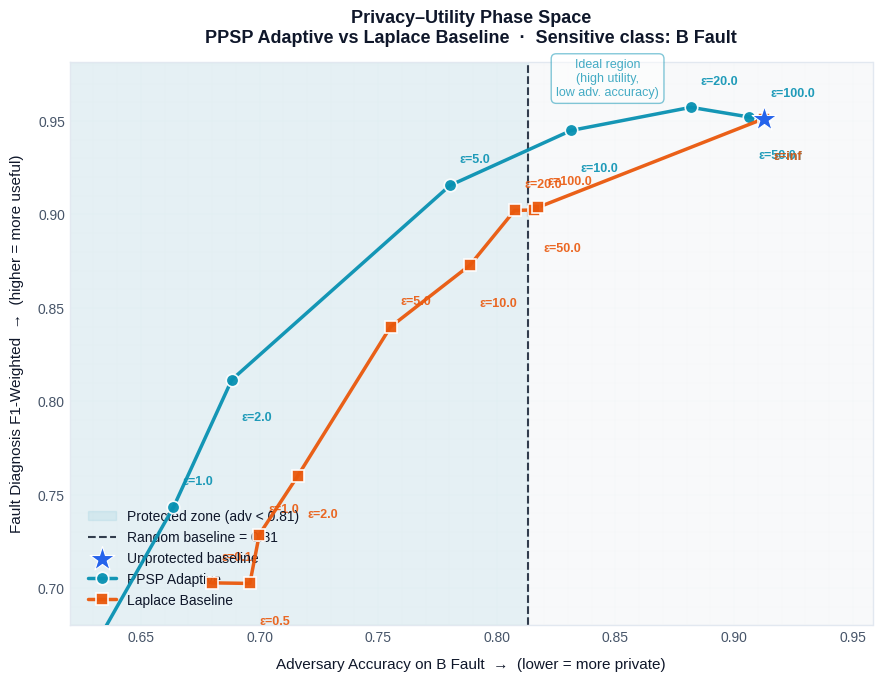

  ✓ Saved: fig1_privacy_utility_phase.png


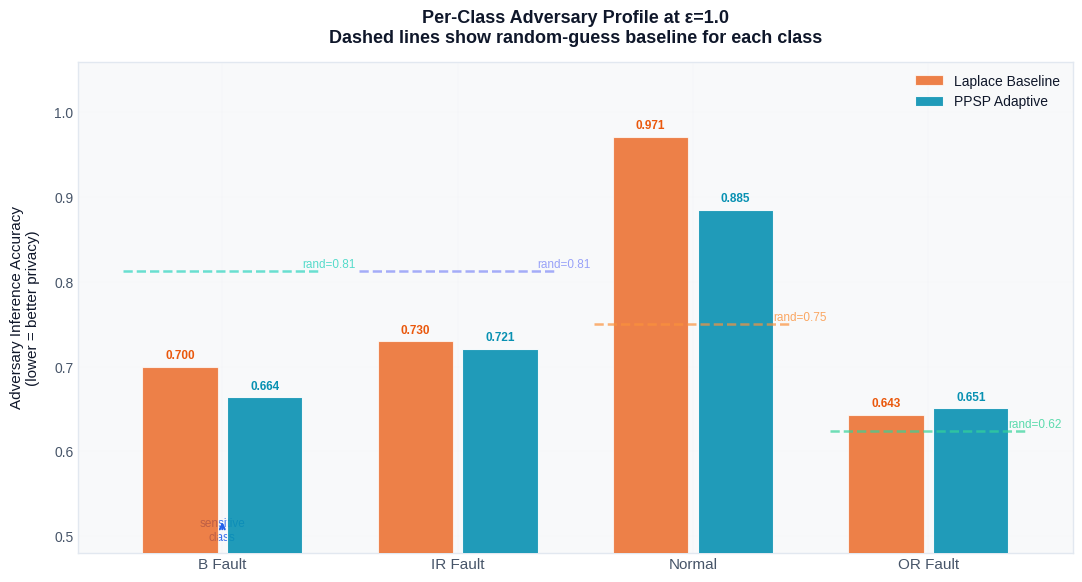

  ✓ Saved: fig2_per_class_adversary.png


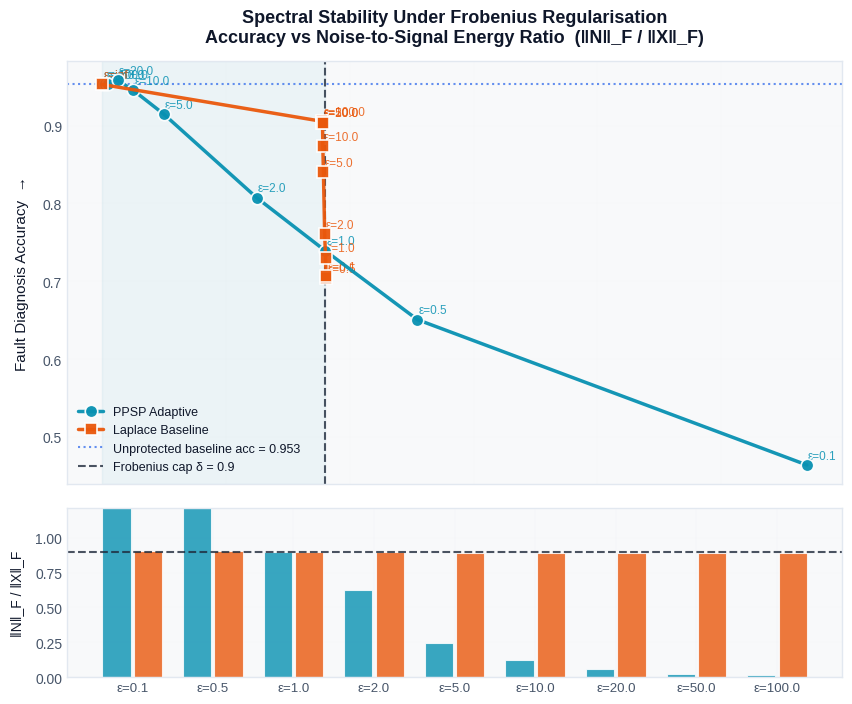

  ✓ Saved: fig3_spectral_stability.png

✓ All figures saved.


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import numpy as np

# ═══════════════════════════════════════════════════════════════════════════
# DESIGN SYSTEM
# ═══════════════════════════════════════════════════════════════════════════
# Palette: deep navy bg with teal (PPSP) and coral (Laplace), clean white text
# Publication-ready: 300 DPI, tight layout, IEEE-style proportions

# Neutral, Print-Friendly Base
BG_COLOR      = "#FFFFFF"   # Pure white for paper integration
PANEL_COLOR   = "#F8F9FA"   # Extremely subtle grey for panel backgrounds
GRID_COLOR    = "#E2E8F0"   # Light grey (won't distract from data)
TEXT_COLOR    = "#0F172A"   # Deep slate/black for legibility
SUBTEXT_COLOR = "#475569"   # Muted slate for axis labels
ZERO_LINE     = "#1E293B"   # Bold slate for the origin/baseline

# High-Contrast Comparative Colors
PPSP_COLOR    = "#0891B2"   # Academic Cyan (Deep Teal)
LAPLACE_COLOR = "#EA580C"   # Burnt Orange (Stands out from teal)
BASELINE_COLOR= "#2563EB"   # Royal Blue (Standard for control/baseline)

# Class accent colours for per-class bars
CLASS_PALETTE = {
    "B":      "#2DD4BF",   # teal  — the sensitive class
    "IR":     "#818CF8",   # indigo
    "Normal": "#FB923C",   # orange
    "OR":     "#34D399",   # emerald
}

def apply_base_style():
    plt.rcParams.update({
        "figure.facecolor"   : BG_COLOR,
        "axes.facecolor"     : PANEL_COLOR,
        "axes.edgecolor"     : GRID_COLOR,
        "axes.labelcolor"    : TEXT_COLOR,
        "axes.titlecolor"    : TEXT_COLOR,
        "xtick.color"        : SUBTEXT_COLOR,
        "ytick.color"        : SUBTEXT_COLOR,
        "text.color"         : TEXT_COLOR,
        "grid.color"         : GRID_COLOR,
        "grid.linewidth"     : 0.2,
        "grid.alpha"         : 0.5,
        "legend.facecolor"   : "#1E293B",
        "legend.edgecolor"   : GRID_COLOR,
        "legend.labelcolor"  : TEXT_COLOR,
        "font.family"        :"sans-serif",
        "font.size"          : 9,
        "axes.titlesize"     : 10,
        "axes.labelsize"     : 10,
        "xtick.labelsize"    : 10,
        "ytick.labelsize"    : 10,
    })

apply_base_style()


def plot_comprehensive_research_results(sweep_results, class_names, y_test):
    """
    Publication-quality 3-panel visualization suite for the PPSP paper.

    Panel 1 — Privacy-Utility Phase Space
    Panel 2 — Per-Class Adversary Profile at ε=1.0
    Panel 3 — Spectral Stability (Frobenius ratio vs Accuracy)
    """

    # ── 0. Pre-compute baselines ──────────────────────────────────────────
    total = len(y_test)
    binary_baselines = {}
    for idx, name in enumerate(class_names):
        prop = np.sum(y_test == idx) / total
        binary_baselines[name] = max(prop, 1.0 - prop)

    target_name = class_names[CFG["sensitive_class"]]
    target_col  = f"adv_acc_{target_name}"
    target_bl   = binary_baselines[target_name]

    # ── Shared aesthetics ─────────────────────────────────────────────────
    STYLES = {
        "ppsp_adaptive"   : dict(color=PPSP_COLOR,    marker="o",
                                  label="PPSP Adaptive",    lw=2.5, ms=9),
        "laplace_baseline": dict(color=LAPLACE_COLOR, marker="s",
                                  label="Laplace Baseline",  lw=2.5, ms=9),
    }

    # ═════════════════════════════════════════════════════════════════════
    # FIGURE 1 — Privacy-Utility Phase Space
    # ═════════════════════════════════════════════════════════════════════
    fig1, ax = plt.subplots(figsize=(9, 7), facecolor=BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)

    # Shaded "privacy protected" region (left of random baseline)
    ax.axvspan(0, target_bl, alpha=0.08, color=PPSP_COLOR,
               label=f"Protected zone (adv < {target_bl:.2f})")

    # Random baseline vertical
    ax.axvline(target_bl, color=ZERO_LINE, linestyle="--", lw=1.5, alpha=0.9,
               label=f"Random baseline = {target_bl:.2f}")

    # Unprotected baseline star
    base_row = sweep_results["ppsp_adaptive"]
    base_row = base_row[base_row["label"] == "Baseline"].iloc[0]
    ax.scatter(base_row[target_col], base_row["f1_weighted"],
               color=BASELINE_COLOR, marker="*", s=350, zorder=12,
               label="Unprotected baseline", edgecolors="white", linewidths=0.8)

    for method, df in sweep_results.items():
        s   = STYLES[method]
        sw  = df[df["epsilon"].notna()].copy().sort_values("epsilon")

        # Main trajectory line
        ax.plot(sw[target_col], sw["f1_weighted"],
                color=s["color"], marker=s["marker"],
                linewidth=s["lw"], markersize=s["ms"],
                label=s["label"], zorder=8, alpha=0.95,
                markerfacecolor=s["color"], markeredgecolor=BG_COLOR,
                markeredgewidth=1.2)

        # Epsilon labels — offset alternately to avoid overlap
        for i, (_, row) in enumerate(sw.iterrows()):
            dy = 0.012 if i % 2 == 0 else -0.022
            dx = 0.004
            ax.annotate(
                f"ε={row['epsilon']:.1f}",
                xy=(row[target_col], row["f1_weighted"]),
                xytext=(row[target_col] + dx, row["f1_weighted"] + dy),
                fontsize=9, color=s["color"], alpha=0.9,
                fontweight="semibold",
            )

    # Axes
    ax.set_xlabel(f"Adversary Accuracy on {target_name} Fault  →  (lower = more private)",
                  fontsize=11, labelpad=10)
    ax.set_ylabel("Fault Diagnosis F1-Weighted  →  (higher = more useful)",
                  fontsize=11, labelpad=10)
    ax.set_title(
        f"Privacy–Utility Phase Space\n"
        f"PPSP Adaptive vs Laplace Baseline  ·  Sensitive class: {target_name} Fault",
        fontsize=13, pad=14, fontweight="bold"
    )

    # Annotation: ideal corner
    ax.annotate("Ideal region\n(high utility,\nlow adv. accuracy)",
                xy=(0.67, 0.94), xycoords="axes fraction",
                fontsize=9, color=PPSP_COLOR, alpha=0.75,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=BG_COLOR,
                          edgecolor=PPSP_COLOR, alpha=0.5))

    ax.set_xlim(left=0.62)
    ax.set_ylim(bottom=0.68)
    ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    ax.yaxis.set_minor_locator(MultipleLocator(0.01))
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)
    ax.legend(loc="lower left", framealpha=0.85, fontsize=10,
              borderpad=0.8, handlelength=2)

    fig1.tight_layout(pad=1.5)
    fig1.savefig("fig1_privacy_utility_phase.png", dpi=300,
                 bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    print("  ✓ Saved: fig1_privacy_utility_phase.png")

    # ═════════════════════════════════════════════════════════════════════
    # FIGURE 2 — Per-Class Adversary Profile at ε=1.0
    # ═════════════════════════════════════════════════════════════════════
    eps_val = 1.0
    if eps_val not in CFG["epsilons"]:
        print(f"  ⚠ ε={eps_val} not in CFG['epsilons'] — skipping Chart 2")
    else:
        fig2, ax = plt.subplots(figsize=(11, 6), facecolor=BG_COLOR)
        ax.set_facecolor(PANEL_COLOR)

        n_classes = len(class_names)
        x         = np.arange(n_classes)
        width     = 0.32
        gap       = 0.04

        lapl_vals = [
            sweep_results["laplace_baseline"]
            .query(f"epsilon == {eps_val}")[f"adv_acc_{c}"].values[0]
            for c in class_names
        ]
        ppsp_vals = [
            sweep_results["ppsp_adaptive"]
            .query(f"epsilon == {eps_val}")[f"adv_acc_{c}"].values[0]
            for c in class_names
        ]

        # Bars
        bars_l = ax.bar(x - width/2 - gap/2, lapl_vals, width,
                        color=LAPLACE_COLOR, alpha=0.75,
                        label="Laplace Baseline", zorder=4,
                        edgecolor=BG_COLOR, linewidth=0.8)
        bars_p = ax.bar(x + width/2 + gap/2, ppsp_vals, width,
                        color=PPSP_COLOR, alpha=0.9,
                        label="PPSP Adaptive", zorder=4,
                        edgecolor=BG_COLOR, linewidth=0.8)

        # Per-class random baseline dashes
        for idx, cname in enumerate(class_names):
            bl = binary_baselines[cname]
            ax.hlines(bl, idx - width - gap/2 - 0.08,
                         idx + width + gap/2 + 0.08,
                      colors=CLASS_PALETTE.get(cname, ZERO_LINE),
                      linestyles="--", lw=1.8, alpha=0.7, zorder=6)
            ax.annotate(f"rand={bl:.2f}", xy=(idx + width/2 + 0.18, bl + 0.004),
                        fontsize=8.5, color=CLASS_PALETTE.get(cname, ZERO_LINE),
                        alpha=0.8)

        # Value labels on bars
        for bar in bars_l:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                    f"{h:.3f}", ha="center", va="bottom",
                    fontsize=8.5, color=LAPLACE_COLOR, fontweight="semibold")
        for bar in bars_p:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                    f"{h:.3f}", ha="center", va="bottom",
                    fontsize=8.5, color=PPSP_COLOR, fontweight="semibold")

        # Sensitive class indicator
        ax.annotate("", xy=(CFG["sensitive_class"], 0.52),
                    xytext=(CFG["sensitive_class"], 0.505),
                    arrowprops=dict(arrowstyle="->", color=BASELINE_COLOR,
                                   lw=1.5))
        ax.text(CFG["sensitive_class"], 0.495, "sensitive\nclass",
                ha="center", fontsize=8.5, color=BASELINE_COLOR, alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels([f"{c} Fault" if c != "Normal" else c
                            for c in class_names], fontsize=11)
        ax.set_ylim(0.48, 1.06)
        ax.set_ylabel("Adversary Inference Accuracy\n(lower = better privacy)",
                      fontsize=11, labelpad=10)
        ax.set_title(
            f"Per-Class Adversary Profile at ε={eps_val}\n"
            f"Dashed lines show random-guess baseline for each class",
            fontsize=13, pad=14, fontweight="bold"
        )
        ax.legend(loc="upper right", framealpha=0.85, fontsize=10)
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)

        fig2.tight_layout(pad=1.5)
        fig2.savefig("fig2_per_class_adversary.png", dpi=300,
                     bbox_inches="tight", facecolor=BG_COLOR)
        plt.show()
        print("  ✓ Saved: fig2_per_class_adversary.png")

    # ═════════════════════════════════════════════════════════════════════
    # FIGURE 3 — Spectral Stability
    # ═════════════════════════════════════════════════════════════════════
    fig3, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 8), facecolor=BG_COLOR,
        gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08}
    )

    for ax in (ax_top, ax_bot):
        ax.set_facecolor(PANEL_COLOR)

    # ── Top: accuracy vs frob_ratio ───────────────────────────────────────
    for method, df in sweep_results.items():
        s  = STYLES[method]
        sw = df[df["epsilon"].notna()].copy().sort_values("frob_ratio")

        ax_top.plot(sw["frob_ratio"], sw["accuracy"],
                    color=s["color"], marker=s["marker"],
                    linewidth=s["lw"], markersize=s["ms"],
                    label=s["label"], zorder=8, alpha=0.95,
                    markerfacecolor=s["color"], markeredgecolor=BG_COLOR,
                    markeredgewidth=1.2)

        for _, row in sw.iterrows():
            ax_top.annotate(
                f"ε={row['epsilon']:.1f}",
                xy=(row["frob_ratio"], row["accuracy"]),
                xytext=(row["frob_ratio"] + 0.005, row["accuracy"] + 0.008),
                fontsize=8.5, color=s["color"], alpha=0.85,
            )

    # Baseline and budget lines
    base_acc = sweep_results["ppsp_adaptive"]
    base_acc = base_acc[base_acc["label"] == "Baseline"]["accuracy"].values[0]
    ax_top.axhline(base_acc, color=BASELINE_COLOR, linestyle=":", lw=1.5,
                   alpha=0.7, label=f"Unprotected baseline acc = {base_acc:.3f}")
    ax_top.axvline(CFG["delta_frob"], color=ZERO_LINE, linestyle="--", lw=1.5,
                   alpha=0.8, label=f"Frobenius cap δ = {CFG['delta_frob']}")

    # Shade allowed perturbation region
    ax_top.axvspan(0, CFG["delta_frob"], alpha=0.05, color=PPSP_COLOR)

    ax_top.set_ylabel("Fault Diagnosis Accuracy  →", fontsize=11, labelpad=10)
    ax_top.set_title(
        "Spectral Stability Under Frobenius Regularisation\n"
        "Accuracy vs Noise-to-Signal Energy Ratio  (‖N‖_F / ‖X‖_F)",
        fontsize=13, pad=14, fontweight="bold"
    )
    ax_top.legend(loc="lower left", framealpha=0.85, fontsize=9)
    ax_top.grid(True, alpha=0.3)
    ax_top.tick_params(labelbottom=False)

    # ── Bottom: frob_ratio bar across epsilons ────────────────────────────
    eps_list = sorted(CFG["epsilons"])
    x_eps    = np.arange(len(eps_list))
    w        = 0.35

    for i, (method, df) in enumerate(sweep_results.items()):
        s   = STYLES[method]
        vals = []
        for eps in eps_list:
            row = df[df["epsilon"] == eps]
            vals.append(row["frob_ratio"].values[0] if len(row) else 0)
        offset = (i - 0.5) * (w + 0.04)
        ax_bot.bar(x_eps + offset, vals, w, color=s["color"],
                   alpha=0.8, label=s["label"], edgecolor=BG_COLOR, lw=0.8)

    ax_bot.axhline(CFG["delta_frob"], color=ZERO_LINE, linestyle="--",
                   lw=1.5, alpha=0.8)
    ax_bot.set_xticks(x_eps)
    ax_bot.set_xticklabels([f"ε={e}" for e in eps_list], fontsize=9.5)
    ax_bot.set_ylabel("‖N‖_F / ‖X‖_F", fontsize=10, labelpad=8)
    ax_bot.set_ylim(0, CFG["delta_frob"] * 1.35)
    ax_bot.grid(True, axis="y", alpha=0.3)
    ax_bot.set_axisbelow(True)

    fig3.tight_layout(pad=1.5)
    fig3.savefig("fig3_spectral_stability.png", dpi=300,
                 bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    print("  ✓ Saved: fig3_spectral_stability.png")

    print("\n✓ All figures saved.")


# ── EXECUTE ────────────────────────────────────────────────────────────────
plot_comprehensive_research_results(sweep_results, CFG["class_names"], y_test)